In [50]:
import numpy as np
from tabulate import tabulate                   # Para generar tablas
import matplotlib.pyplot as plt

from sklearn import datasets                    # Módulo para levantar los datos
from sklearn.metrics import accuracy_score      # Medida de precisión
from sklearn.model_selection import KFold       # Modelo de partición

# Clasificadores:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

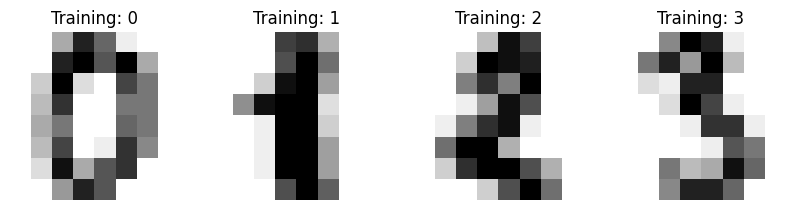

In [68]:
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))

for ax, image, label in zip(axes, digits.images, digits.target): 
  ax.set_axis_off()
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title("Training: %i" % label)

In [52]:
X_digits, y_digits = datasets.load_digits(return_X_y=True)

In [53]:
ACC_mean = []

# Naive Bayes

In [54]:
# Definimos el modelo
gnb = GaussianNB()

kf = KFold(n_splits=5, random_state=42, shuffle=True)

ACC = []

for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
    X_train, y_train = X_digits[train_index], y_digits[train_index]
    X_test, y_test = X_digits[test_index], y_digits[test_index]
    # Entrenamiento del modelo
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    acc_fold = accuracy_score(y_test, y_pred)
    ACC.append(acc_fold)
        
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Naive Bayes", np.mean(ACC)))
# Creamos una tabla
table_data = []
for i in range(len(ACC)):
    table_data.append({"Fold": i+1, "Accuracy": ACC[i]})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

% de aciertos medios: 0.8391674404209223
Varianza de la exactitud: 0.0003701695678499866
┌────────┬────────────┐
│  Fold  │  Accuracy  │
├────────┼────────────┤
│   1    │  0.847222  │
├────────┼────────────┤
│   2    │  0.847222  │
├────────┼────────────┤
│   3    │  0.802228  │
├────────┼────────────┤
│   4    │  0.857939  │
├────────┼────────────┤
│   5    │  0.841226  │
└────────┴────────────┘


# Analisis discriminante lineal

In [55]:
# Definimos el modelo
clf = LinearDiscriminantAnalysis()

kf = KFold(n_splits=5, random_state=42, shuffle=True)

ACC = []

for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
    X_train, y_train = X_digits[train_index], y_digits[train_index]
    X_test, y_test = X_digits[test_index], y_digits[test_index]
    # Entrenamiento del modelo
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc_fold = accuracy_score(y_test, y_pred)
    ACC.append(acc_fold)
        
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("ADL", np.mean(ACC)))
# Creamos una tabla
table_data = []
for i in range(len(ACC)):
    table_data.append({"Fold": i+1, "Accuracy": ACC[i]})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

% de aciertos medios: 0.9521340142370782
Varianza de la exactitud: 0.0002465860793586883
┌────────┬────────────┐
│  Fold  │  Accuracy  │
├────────┼────────────┤
│   1    │  0.944444  │
├────────┼────────────┤
│   2    │   0.975    │
├────────┼────────────┤
│   3    │  0.938719  │
├────────┼────────────┤
│   4    │  0.966574  │
├────────┼────────────┤
│   5    │  0.935933  │
└────────┴────────────┘


In [56]:
def generar_kfold(X_digits, y_digits, clf, n_folds=5):
  kf = KFold(n_splits=5, random_state=42, shuffle=True)
  ACC = []

  for fold, (train_index, test_index) in enumerate(kf.split(X_digits)): 
      X_train, y_train = X_digits[train_index], y_digits[train_index]
      X_test, y_test = X_digits[test_index], y_digits[test_index]
      # Entrenamiento del modelo
      clf.fit(X_train, y_train)
      y_pred = clf.predict(X_test)
      acc_fold = accuracy_score(y_test, y_pred)
      ACC.append(acc_fold)

  return ACC


# K-Vecinos mas cercanos

In [57]:
print("-------------- K = 1 --------------")
clf = KNeighborsClassifier(n_neighbors=1)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=1)", np.mean(ACC)))

-------------- K = 1 --------------
% de aciertos medios: 0.9877607551841535
Varianza de la exactitud: 5.751617364319533e-05


In [58]:
print("-------------- K = 2 --------------")
clf = KNeighborsClassifier(n_neighbors=2)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=2)", np.mean(ACC)))

-------------- K = 2 --------------
% de aciertos medios: 0.9844165892912411
Varianza de la exactitud: 7.322907503629791e-05


In [59]:
print("-------------- K = 5 --------------")
clf = KNeighborsClassifier(n_neighbors=5)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=5)", np.mean(ACC)))

-------------- K = 5 --------------
% de aciertos medios: 0.9860832559579078
Varianza de la exactitud: 6.833199848151633e-05


In [60]:
print("-------------- K = 10 --------------")
clf = KNeighborsClassifier(n_neighbors=10)
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("K-means (K=10)", np.mean(ACC)))

-------------- K = 10 --------------
% de aciertos medios: 0.9821866295264625
Varianza de la exactitud: 6.404391992958174e-05


#  Arbol de decision

In [61]:
clf = DecisionTreeClassifier(criterion="gini")
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Arbol de decision", np.mean(ACC)))

% de aciertos medios: 0.8603156917363046
Varianza de la exactitud: 0.00017683022935982372


# Maquina de soporte vectorial
Para este clasificador, debido a que no es invariante en escala, utilizamos la funcion StandarScaler() para escalar los datos, estandarizandoos para que tengan media 0 y varianza 1

### Linear

In [62]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="linear"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (Linear)", np.mean(ACC)))


% de aciertos medios: 0.9738362735995049
Varianza de la exactitud: 0.00010760389452955979


### Polynomial Kernel

In [63]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="poly"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (Poly)", np.mean(ACC)))


% de aciertos medios: 0.9493500464252553
Varianza de la exactitud: 0.00040237278411964054


### Radial basis Function

In [64]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="rbf"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (RBF)", np.mean(ACC)))


% de aciertos medios: 0.9794103992571961
Varianza de la exactitud: 2.667486065478492e-05


### Sigmoid Kernel

In [65]:
clf = make_pipeline(StandardScaler(), SVC(gamma="auto", kernel="sigmoid"))
ACC = generar_kfold(X_digits, y_digits, clf)
print(f"% de aciertos medios: {np.mean(ACC)}")
print(f"Varianza de la exactitud: {np.var(ACC)}")
ACC_mean.append(("Maquina de soporte vectorial (Sigmoid)", np.mean(ACC)))


% de aciertos medios: 0.9504766326214794
Varianza de la exactitud: 7.816897509339902e-05


In [66]:
# Creamos una tabla
ACC_mean = sorted(ACC_mean, key=lambda x: x[1], reverse=True)

table_data = []
for nombre, acc in ACC_mean:
    table_data.append({"Método": nombre, "Accuracy": acc})

table = tabulate(table_data, headers="keys", tablefmt="simple_grid", stralign="center", numalign='center')
print(table)

┌────────────────────────────────────────┬────────────┐
│                 Método                 │  Accuracy  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=1)              │  0.987761  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=5)              │  0.986083  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=2)              │  0.984417  │
├────────────────────────────────────────┼────────────┤
│             K-means (K=10)             │  0.982187  │
├────────────────────────────────────────┼────────────┤
│   Maquina de soporte vectorial (RBF)   │  0.97941   │
├────────────────────────────────────────┼────────────┤
│ Maquina de soporte vectorial (Linear)  │  0.973836  │
├────────────────────────────────────────┼────────────┤
│                  ADL                   │  0.952134  │
├────────────────────────────────────────┼────────────┤
│ Maquina de soporte vectorial (Sigmoid) │  0.95